
Naive: perm $(A)=\sum\limits_{\sigma \in S_n} \prod\limits_{i=1}^n a_{i,\sigma(i)}, S_n=\lvert S\rvert!_n, S=\{1, ..., n\}, n=\lvert A \rvert$ $\mathcal{O}(n!n)$

Ryser: perm $(A)=(-1)^n\sum\limits_{S\subseteq \{1,...,n\}} (-1)^{\lvert S\rvert} \prod\limits_{i=1}^n \sum\limits_{j\in S} a_{i,j} \equiv (-1)^{n-1}2*\sum\limits_{S\subseteq \{1,...,n-1\}} (-1)^{\lvert S\rvert} \prod\limits_{i=1}^n (x_i + \sum\limits_{j \in S} a_{i, j}), x_i=a_{i, n}-\frac{1}{2}\sum\limits_{j=1}^n a_{i, j}$

Balasubramanian-Bax-Franklin-Glynn: perm $(A)=\frac{1}{2^{n-1}}\sum\limits_\delta (\prod\limits_{k=1}^n \delta_k) \prod\limits_{j=1}^n \sum\limits_{i=1}^n \delta_i a_{i, j}, \delta \subseteq \{1\}\mathbin\Vert\{\pm 1\}^{(n-1)}, n=\lvert A \rvert$ $\mathcal{O}(2^{n-1}n)$

Loop-Hafnian loop corrections: lc $(\lambda, B)=\sum\limits_{k=1}^{n/2} \frac{vB^{k-1}Xv^\intercal}{2}\lambda^k, v=\text{diag}(B), X=\bigoplus\limits_{i=1}^{n/2} \sigma_x, \sigma_x=\begin{bmatrix} 0 & 1\\1 & 0\end{bmatrix}, n=\lvert B \rvert$

Optimized Loop-Hafnian loop corrections: $vB^{k-1}Xv^\intercal\equiv v\cdot \text{lco}(Xv^\intercal, k), \text{lco}(w, c)=\begin{cases} w & c == 1\\ \text{lco}(Bw, c-1) & \text{otherwise}\end{cases}$

Loop Torontonian definition: https://arxiv.org/pdf/2202.04600.pdf

Recursive Loop Torontonian algorithm:

input : $A$ an $N × N$ sampling matrix defined by Eq. (1), gamma an $N$ loop mode vector

output: The calculated Loop Torontonian tor

1 L = cholesky $(I − A)$;

2 det $(I − A)$ = $\prod\limits_{i=0}^{N-1} |L_{ii}|^2$;

3 lc = gamma $*($L^{-1}*(L^{-\dagger}*\text{gamma}^\intercal))$

4 tor = $\frac{\text{exp}(\frac{\text{lc}}{2})}{\sqrt{|det(I-A)}}$;

5 recursiveLTor(L, [], gamma);

6 function recursiveLTor(L, modes, gammaL):

7 if (size(modes) == 0) :

8   start = 0;

9 else:

10   start = modes[end] + 1;

11 for (i = start; i < N/2; i++) :

12   nextModes = modes + [i];

13   $A_Z$ = createAZ(L, nextModes);

14   $\tilde{L}$ = cholesky $(I − A_Z)$;

15   gammaX = createGamma(gammaL, nextModes);

16   lc = gammaX $*(\tilde{L}^{-1}*(\tilde{L}^{-\dagger}*\text{gammaX}^\intercal))$

17   determinant = $\prod\limits_{i=0}^{N-2|\text{nextModes}|-1} |\tilde{L}_{ii}|^2$;

18   tor = tor + $\frac{(−1)^{|\text{nextModes}|}*\text{exp}(\frac{\text{lc}}{2})}{\sqrt{\text{determinant}}}$;

19   recursiveTor($\tilde{L}$, nextModes, gammaX);

20 return;

$A=L*L^\dagger, A^{-1}=L^{-\dagger}*L^{-1}$

$v*A*v^\dagger=v*L^{-\dagger}*L^{-1}*v^\dagger=(L^{-1}*v^\dagger)^\dagger*L^{-1}*v^\dagger=|L^{-1}*v^\dagger|^2$

Upper triangular * lower triangular * vector efficient solution: https://www.caam.rice.edu/~yzhang/caam335/F09/handouts/lu.pdf or function dtrsv in LAPACK/BLAS http://www.netlib.org/lapack/explore-html/d6/d96/dtrsv_8f.html

In [24]:
import numpy as np
import numba
@numba.jit(nopython=True)
def nb_ix(arr, rows, cols):
  return arr[rows][:, cols]
@numba.jit(nopython=True) #, cache=True)
def find_kept_edges(j, reps):  # pragma: no cover
    """Write ``j`` as a string where the ith digit is in base ``reps[i]+1``
    decides which edges are included given index of the inclusion/exclusion sum.
    Args:
        j (int): index of sum
        reps (list): number of repetitions of each edge
    Returns:
        array: number of repetitions kept for the current inclusion/exclusion step
    """
    num = j
    output = []
    bases = np.asarray(reps) + 1
    for base in bases[::-1]:
        output.append(num % base)
        num //= base
    return np.array(output[::-1], dtype=reps.dtype)
@numba.jit(nopython=True, parallel=True)
def numba_ltor(O, gamma):  # pragma: no cover
    r"""Returns the loop Torontonian of a matrix using numba.
    Args:
        O (array): a square, symmetric array of even dimensions.
        gamma (array): a vector of even dimension
    Returns:
        np.complex128: the loop torontonian of matrix O, vector gamma
    """
    N = O.shape[0] // 2
    N_odd = N % 2

    steps = 2**N
    ones = np.ones(N, dtype=np.int8)

    gamma = gamma.astype(np.complex128)
    O = O.astype(np.complex128)

    total = 0.0
    for j in numba.prange(steps):
        X_modes = find_kept_edges(j, ones)
        lenX = X_modes.sum()
        I = np.eye(2 * lenX, dtype=O.dtype)
        plusminus = (-1) ** ((N_odd - lenX % 2) % 2)

        kept_modes = np.where(X_modes != 0)[0]
        kept_rows = np.concatenate((kept_modes, kept_modes + N))
        O_XX = nb_ix(O, kept_rows, kept_rows)

        I_m_O_XX = I - O_XX
        I_m_O_XX_inv = np.linalg.inv(I_m_O_XX)

        gamma_X = gamma[kept_rows]
        top = np.exp(0.5 * gamma_X @ I_m_O_XX_inv @ gamma_X.conj())
        bottom = np.sqrt(O.dtype.type(np.real(np.linalg.det(I_m_O_XX))))

        total += plusminus * top / bottom

    return total
#permutation parity is needed which is complex as sorting if not maintained during generation, although cycle decomposition can linearize it
#https://github.com/python/cpython/blob/main/Modules/itertoolsmodule.c
def permutations(iterable, r=None):
  pool = tuple(iterable)
  n = len(pool)
  r = n if r is None else r
  if r > n: return
  indices = list(range(n))
  cycles = list(range(n, n-r, -1))
  parity = 0
  yield tuple(pool[i] for i in indices[:r]), parity
  while n:
    for i in reversed(range(r)):
      cycles[i] -= 1
      if cycles[i] == 0:
        if ((n-i) & 1) == 0: parity = 1 - parity
        indices[i:] = indices[i+1:] + indices[i:i+1]
        cycles[i] = n - i
      else:
        j = cycles[i]
        parity, indices[i], indices[-j] = 1 - parity, indices[-j], indices[i]
        yield tuple(pool[i] for i in indices[:r]), parity
        break
    else: return
def dosign(parity, x): return -x if parity else x
def prod(x, y): return x * y
def multiprod(l):
  import functools
  return functools.reduce(prod, l)
def determinant(mat):
  n = len(mat)
  if n == 0: return 0
  return sum(dosign(parity, multiprod((mat[i][sigma[i]] for i in range(n)))) for sigma, parity in permutations(range(n)))
#https://the-walrus.readthedocs.io/en/latest/_modules/thewalrus/_torontonian.html
def powerset(s): #empty set handled as special case
  import itertools
  for i in range(1, len(s)+1):
    yield from itertools.combinations(s, i)
#https://the-walrus.readthedocs.io/en/latest/code/quantum.html pip install thewalrus
def genident(n):
  return [[1 if i == j else 0 for j in range(n)] for i in range(n)]
def submat(A, B): n = len(A); return [[A[i][j] - B[i][j] for j in range(n)] for i in range(n)]
def matix(mat, ix): return [[mat[i][j] for j in ix] for i in ix]
def torontonian(mat):
  N = len(mat); assert((N & 1) == 0) #N=2*d
  N >>= 1 #determinant of empty matrix is 1
  return sum((1 if ((N - len(Z)) & 1) == 0 else -1)
             /np.sqrt(determinant(submat(genident(len(Z)<<1), matix(mat, [*Z, *(x + N for x in Z)]))))
             for Z in powerset(list(range(N)))) + (1 if (N & 1) == 0 else -1)
def matMul(mat1, mat2):
  m1, n1, m2, n2 = len(mat1), len(mat1[0]), len(mat2), len(mat2[0])
  assert n1 == m2
  out = [[0 for _ in range(n2)] for _ in range(m1)]
  for i in range(m1):
    for j in range(n2):
      for k in range(n1):
        out[i][j] += mat1[i][k] * mat2[k][j]
  return out
def matInv(mat): #change to Gaussian elimination
  return np.linalg.inv(mat)
def ltorontonian(mat, gamma):
  N = len(mat); assert((N & 1) == 0) #N=2*d
  N >>= 1 #determinant of empty matrix is 1
  def subcalc(Z):
    kept_modes = [*Z, *(x + N for x in Z)]
    gamma_X = [gamma[i] for i in kept_modes]
    nmat = submat(genident(len(Z)<<1), matix(mat, kept_modes))
    return ((1 if ((N - len(Z)) & 1) == 0 else -1)*np.exp(0.5 * matMul([gamma_X], matMul(matInv(nmat), [[x.conjugate()] for x in gamma_X]))[0][0])
             /np.sqrt(determinant(nmat)))
  return sum(subcalc(Z) for Z in powerset(list(range(N)))) + (1 if (N & 1) == 0 else -1)

#https://en.wikipedia.org/wiki/Cholesky_decomposition
def cholesky(mat): #Cholesky–Banachiewicz algorithm
  #return [] if len(mat) == 0 else np.linalg.cholesky(mat)
  n = len(mat)
  L = [[0. for _ in range(n)] for _ in range(n)]
  for i in range(n):
    for j in range(i):
      L[i][j] = (mat[i][j] - sum(L[i][k]*L[j][k].conjugate() for k in range(j)))/L[j][j]
    L[i][i] = np.sqrt(mat[i][i] - sum(L[i][k]*L[i][k].conjugate() for k in range(i)))
  #if n != 0: print(L, np.linalg.cholesky(mat))
  return L
def quad_cholesky(L, Z, idx, mat):
  Ls = matix(L, Z)
  for i in range(idx, len(mat)):
    for j in range(idx, i):
      Ls[i][j] = (mat[i][j] - sum(Ls[i][k]*Ls[j][k].conjugate() for k in range(j)))/Ls[j][j]
    Ls[i][i] = np.sqrt(mat[i][i] - sum(Ls[i][k]*Ls[i][k].conjugate() for k in range(i)))
  return Ls
#https://arxiv.org/pdf/2109.04528.pdf
def rec_torontonian(mat):
  def recursiveTor(L, modes, mat, n):
    tor, start = 0., 0 if len(modes) == 0 else modes[-1]+1
    for i in range(start, n):
      nextModes = modes + [i]
      nm, idx = len(mat) >> 1, (i - len(modes))*2
      Z = [x for x in range(nm*2) if x != idx and x != idx+1]
      Az = matix(mat, Z); nm -= 1
      #Ls = cholesky(submat(genident(2*nm), Az))
      Ls = quad_cholesky(L, Z, idx, submat(genident(2*nm), Az))
      det = 1 if nm == 0 else multiprod((Ls[i][i]*Ls[i][i] for i in range(2*nm)))
      tor += (1 if (len(nextModes) & 1) == 0 else -1)/np.sqrt(det) + recursiveTor(Ls, nextModes, Az, n)
    return tor
  n = len(mat) >> 1
  mat = matix(mat, [j for i in range(n) for j in (i, i + n)])
  L = cholesky(submat(genident(2*n), mat))
  det = multiprod((L[i][i]*L[i][i] for i in range(2*n)))
  return 1/np.sqrt(det) + recursiveTor(L, [], mat, n) #(1 if (n & 1) == 0 else -1)
def rec_ltorontonian(mat, gamma):
  def recursiveTor(L, modes, mat, n, gammarem):
    tor, start = 0., 0 if len(modes) == 0 else modes[-1]+1
    for i in range(start, n):
      nextModes = modes + [i]
      nm, idx = len(mat) >> 1, (i - len(modes))*2
      Z = [x for x in range(nm*2) if x != idx and x != idx+1]
      Az = matix(mat, Z); nm -= 1
      #Ls = cholesky(submat(genident(2*nm), Az))
      Ls = quad_cholesky(L, Z, idx, submat(genident(2*nm), Az))
      gamma_X = [gammarem[i] for i in Z]
      Lsinv = [] if nm == 0 else matMul(matInv(Ls), [[x.conjugate()] for x in gamma_X])
      lc = 0 if nm == 0 else matMul([[x[0].conjugate() for x in Lsinv]], Lsinv)[0][0]
      det = 1 if nm == 0 else multiprod((Ls[i][i]*Ls[i][i] for i in range(2*nm)))
      tor += (1 if (len(nextModes) & 1) == 0 else -1)*np.exp(0.5*lc)/np.sqrt(det) + recursiveTor(Ls, nextModes, Az, n, gamma_X)
    return tor
  n = len(mat) >> 1
  Z = [j for i in range(n) for j in (i, i + n)]
  mat = matix(mat, Z)
  gamma = [gamma[i] for i in Z]
  L = cholesky(submat(genident(2*n), mat))
  det = multiprod((L[i][i]*L[i][i] for i in range(2*n)))
  Ls = matMul(matInv(L), [[x.conjugate()] for x in gamma])
  return np.exp(0.5*matMul([[x[0].conjugate() for x in Ls]], Ls)[0][0])/np.sqrt(det) + recursiveTor(L, [], mat, n, gamma) #(1 if (n & 1) == 0 else -1)


@numba.jit(nopython=True)
def numba_ix(arr, rows, cols):
  return arr[rows][:, cols]
@numba.jit(nopython=True)
def quad_cholesky_np(L, Z, idx, mat):
  Ls = numba_ix(L, Z, Z)
  for i in range(idx, len(mat)):
    for j in range(idx, i):
      z = 0.
      for k in range(j): z += Ls[i,k]*Ls[j,k].conjugate()
      Ls[i,j] = (mat[i][j] - z)/Ls[j,j]
    z = 0.
    for k in range(i): z += Ls[i,k]*Ls[i,k].conjugate()
    Ls[i,i] = L.dtype.type(np.real(np.sqrt(mat[i,i] - z)))
  return Ls
@numba.jit(nopython=True)
def recursiveTor_np(L, modes, A, n):
  tor, start = 0., 0 if len(modes) == 0 else modes[-1]+1
  for i in range(start, n):
    nextModes = np.append(modes, i)
    nm, idx = len(A) >> 1, (i - len(modes))*2
    Z = np.concatenate((np.arange(idx), np.arange(idx+2, nm*2)), axis=0); nm -= 1
    Az = numba_ix(A, Z, Z)
    #Ls = np.linalg.cholesky(np.eye(2*nm) - Az)
    Ls = quad_cholesky_np(L, Z, idx, np.eye(2*nm) - Az)
    det = np.square(np.prod(np.diag(Ls)))
    tor += ((-1) ** len(nextModes))/np.sqrt(det) + recursiveTor_np(Ls, nextModes, Az, n)
  return tor
@numba.jit(nopython=True)
def rec_torontonian_np(A):
  n = A.shape[0] >> 1
  #Z = np.zeros(2*n, dtype=np.int_)
  #for i in range(n): Z[2*i] = i; Z[2*i+1] = i+n
  Z = np.empty((2*n,), dtype=np.int_)
  Z[0::2] = np.arange(0, n)
  Z[1::2] = np.arange(n, 2*n)
  A = numba_ix(A, Z, Z)
  L = np.linalg.cholesky(np.eye(2*n) - A)
  det = np.square(np.prod(np.diag(L)))
  return 1/np.sqrt(det) + recursiveTor_np(L, np.empty(0, dtype=np.int_), A, n)
@numba.jit(nopython=True)
#http://www.netlib.org/lapack/explore-html/d6/d96/dtrsv_8f.html
  #lower triangular, no transpose, not unit triangular, incx=1
def solve_triangular(L, y): #import scipy.linalg as slin; slin.solve_triangular(L,gamma,lower=True)
  n = len(y)
  x = np.copy(y)
  for j in range(0, n):
    if x[j] == 0: continue
    x[j] = x[j] / L[j, j]
    temp = x[j]
    for i in range(j+1, n):
      x[i] -= temp * L[i, j]
  return x
@numba.jit(nopython=True)
def recursiveLTor_np(L, modes, A, n, gammaL):
  tor, start = 0., 0 if len(modes) == 0 else modes[-1]+1
  for i in range(start, n):
    nextModes = np.append(modes, i)
    nm, idx = len(A) >> 1, (i - len(modes))*2
    Z = np.concatenate((np.arange(idx), np.arange(idx+2, nm*2)), axis=0); nm -= 1
    Az = numba_ix(A, Z, Z)
    #Ls = np.linalg.cholesky(np.eye(2*nm) - Az)
    Ls = quad_cholesky_np(L, Z, idx, np.eye(2*nm) - Az)
    det = np.square(np.prod(np.diag(Ls)))
    gammaX = gammaL[Z]
    Lsinv = solve_triangular(Ls, gammaX.conj()) #np.linalg.inv(Ls) @ gammaX.conj()
    lc = Lsinv.conj().T @ Lsinv
    tor += ((-1) ** len(nextModes))*np.exp(0.5*lc)/np.sqrt(det) + recursiveLTor_np(Ls, nextModes, Az, n, gammaX)
  return tor
@numba.jit(nopython=True)
def rec_ltorontonian_np(A, gamma):
  n = A.shape[0] >> 1
  #Z = np.zeros(2*n, dtype=np.int_)
  #for i in range(n): Z[2*i] = i; Z[2*i+1] = i+n
  Z = np.empty((2*n,), dtype=np.int_)
  Z[0::2] = np.arange(0, n)
  Z[1::2] = np.arange(n, 2*n)
  A = numba_ix(A, Z, Z)
  gamma = gamma[Z]
  L = np.linalg.cholesky(np.eye(2*n) - A)
  det = np.square(np.prod(np.diag(L)))
  Ls = solve_triangular(L, gamma.conj()) #np.linalg.inv(L) @ gamma.conj()
  lc = Ls.conj().T @ Ls
  return np.exp(0.5*lc)/np.sqrt(det) + recursiveLTor_np(L, np.empty(0, dtype=np.int_), A, n, gamma)
def test_tor():
  import timeit
  from thewalrus import numba_tor
  from thewalrus.random import random_covariance
  from thewalrus.quantum.conversions import Amat, Xmat
  funcs = (numba_tor, rec_torontonian, rec_torontonian_np)# + (torontonian,)
  for N in range(1, 10):
    cov = random_covariance(N)
    O = Xmat(N) @ Amat(cov)
    v = [f(O) for f in funcs]
    print(v)
    for f in funcs:
      print(timeit.timeit(lambda: f(O), number=1000))
def test_ltor():
  import timeit
  from thewalrus.random import random_covariance
  from thewalrus.quantum.conversions import Amat, Xmat
  funcs = (rec_ltorontonian_np, numba_ltor,) # + (rec_ltorontonian, ltorontonian,)
  t = [[] for _ in funcs]
  n = 10
  for N in range(1,n+1):
    cov = random_covariance(N)
    O = Xmat(N) @ Amat(cov)
    alpha = np.random.random(N) + np.random.random(N) * 1j
    alpha = np.concatenate((alpha, alpha.conj()))
    #mu = np.linspace(-1, 1, 2*N, dtype=np.complex128)
    #mu = mu + mu * 1j
    mu = O @ alpha
    v = [f(O, mu) for f in funcs]
    print(v, np.isclose(v[0], v[1]))
    for i, f in enumerate(funcs):
      t[i].append(timeit.timeit(lambda: f(O, mu), number=5))
  import matplotlib.pyplot as plt
  plt.semilogy(2 * np.arange(1, n + 1),t[0],"x",label="Numba Recursive")
  plt.semilogy(2 * np.arange(1, n + 1),t[1],"+", label="Numba Non-recursive")
  plt.xlabel(r"Matrix size $n$")
  plt.ylabel(r"Time in seconds")
  ax = plt.subplot(111)
  ax.legend()
  plt.savefig("ltor_benchmark.png", format="png")
  plt.savefig("ltor_benchmark.svg", format="svg")

[(0.3210768804763431+0j), (0.3210768804763431+4.0104803867319075e-18j)] True
[(1.3153809068691033e+251+0j), (1.3153809484386917e+251+2.0487185558533925e+240j)] True
[(1.7906822107498289e+31+0j), (1.7906822107606965e+31-5.343896195025585e+18j)] True
[(102721.68122469276+0j), (102721.68122469126+4.61962193228499e-10j)] True
[(347145.4911190479+0j), (347145.49111907196+7.461204844849899e-10j)] True
[(1.1952886161115457e+27+0j), (1.1952886161109689e+27-95812122524603.6j)] True
[(1.405143452696862e+23+0j), (1.4051434526957141e+23+12878466182.128017j)] True
[(nan+nanj), (nan+nanj)] False
[(1.7994248916214284e+19+0j), (1.7994248916210934e+19+181326.20932840207j)] True
[(5.874219579039294e+16+0j), (5.8742195790341256e+16-9276.23298661513j)] True


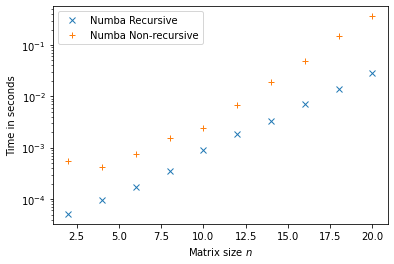

In [25]:
#test_tor()
test_ltor()

In [61]:
size = 4
matrix = 1j * np.ones([size, size])
matrix = np.tril(matrix.conjugate(), -1) + np.triu(matrix, 1) + np.eye(size)*0.5
gamma = np.linspace(-1, 1, 2*size, dtype=np.complex128)
#gamma = np.zeros(2*size, dtype=np.complex128)
#rec_ltorontonian_np(matrix, gamma),
ltorontonian(matrix, gamma), numba_ltor(matrix, gamma)

((1-0.8697185611785869j), (1-0.869718561178588j))

In [34]:
#https://en.wikipedia.org/wiki/Cholesky_decomposition
def symbolic_cholesky(mat): #Cholesky–Banachiewicz algorithm
  #return [] if len(mat) == 0 else np.linalg.cholesky(mat)
  n = len(mat)
  L = [[0. for _ in range(n)] for _ in range(n)]
  for i in range(n):
    for j in range(i):
      L[i][j] = (mat[i][j] - sum(L[i][k]*L[j][k].conjugate() for k in range(j)))/L[j][j]
    L[i][i] = np.sqrt(mat[i][i] - sum(L[i][k]*L[i][k].conjugate() for k in range(i)))
  #if n != 0: print(L, np.linalg.cholesky(mat))
  return L
def mulPolyR(a, b, clen):
  alen, blen = len(a), len(b)
  if (alen == 0): return a
  if (blen == 0): return b
  if clen is None: clen = alen + blen -1
  p = [0] * min(clen, (alen + blen - 1))
  for i in range(0, blen):
    if (b[i] == 0): continue
    for j in range(0, alen):
      if (a[j] == 0) or i + j >= clen: continue
      p[i + j] += a[j] * b[i]
  import itertools
  return list(reversed(list(itertools.dropwhile(lambda c: c == 0, reversed(p)))))
def charpoly(eigvs):
  A = [1]
  for eigv in eigvs:
    A = mulPolyR(A, [1, eigv], None)
  return A
def cholesky_eigenvalues(A):
  n = A.shape[0] >> 1
  print(np.linalg.eigvalsh(A))
  print(charpoly(np.linalg.eigvalsh(A)))
  print(np.linalg.eigvalsh(np.eye(2*n) - A)) #np.linalg.eigvals(A)
  print(charpoly(np.linalg.eigvalsh(np.eye(2*n) - A)))
  L = np.linalg.cholesky(np.eye(2*n) - A)
  print(np.linalg.det(A), np.linalg.det(np.eye(2*n) - A), np.square(np.prod(np.diag(L))))
  #np.eye(2*n) - A == L @ L.conj().transpose()
  #I-A=L*L^\dagger
  #det(tI-A)=det((t+1)I-L*L^\dagger)=det((t+1)I)det(I-L^\dagger*((t+1)I)^-1*L) where (tI)^-1=I/(t+1)
  print(charpoly(L.diagonal()))
  print(charpoly(L.diagonal() * L.conj().diagonal()))

def test_cholesky_eigenvalues():
  from thewalrus.random import random_covariance
  from thewalrus.quantum.conversions import Amat, Xmat
  N = 2
  cov = random_covariance(N)
  O = Xmat(N) @ Amat(cov)
  cholesky_eigenvalues(O)
test_cholesky_eigenvalues()

[-0.90359784 -0.75769946  0.84916789  0.97941207]
[1, 0.16728266058358732, -1.5214740678750576, -0.1297290100600863, 0.569417976977222]
[0.02058793 0.15083211 1.75769946 1.90359784]
[1, 3.832717339416414, 3.9766779503741825, 0.5849328925592101, 0.010390258578663422]
(0.5694179769772223-1.5804523716889741e-15j) (0.010390258578663348-1.788003167405371e-17j) (0.010390258578663413+0j)
[1, (2.6651408965924657+0j), (2.4494924229276536+0j), (0.8861077173947062+0j), (0.10193261783483937+0j)]
[1, (2.2039911528343854+0j), (1.4806745328200042+0j), (0.2858205367552181+0j), (0.010390258578663412+0j)]


In [6]:
#https://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.1067.6055&rep=rep1&type=pdf
def cartesianProductGcode(counterChain, l, k):
    if counterChain == [0] * len(l): return
    for j in range(0, len(l)):
        if all(counterChain[i] == 0 for i in range(j)):
            k[j] = k[j]+1 if k[j] != (l[j] << 1)-1 else 0 #(k[j]+1) modulo 2*l[j]
    #assert k == counterToGcode(counterChain, l), (k, counterToGcode(counterChain, l))
def counterChainMplicity(l):
    import math, functools
    counterChain, k, term = [0] * len(l), [0] * len(l), [x-1 for x in l]
    while True:
        cartesianProductGcode(counterChain, l, k)
        assert k == counterToGcode(counterChain, l), (counterToGcode(counterChain, l), k, counterChain, l)
        #print(counterChain, k, [k[j] if k[j] < l[j] else l[j]*2-k[j]-1 for j in range(len(l))],
        #    functools.reduce(lambda a, b: a * b, [math.comb(l[j]-1, l[j]-1-k[j] if k[j] < l[j] else k[j]-l[j]) for j in range(len(l))]))
        print(tuple(counterChain), "&", tuple(k), "&", tuple([k[j] if k[j] < l[j] else l[j]*2-k[j]-1 for j in range(len(l))]), "&",
            functools.reduce(lambda a, b: a * b, [math.comb(l[j]-1, l[j]-1-k[j] if k[j] < l[j] else k[j]-l[j]) for j in range(len(l))]), "\\\\")
        if counterChain == term: break
        i = 0
        while True:
            if counterChain[i] == l[i]-1: counterChain[i] = 0; i+=1
            else: counterChain[i] += 1; break
def locationToCounter(l, loc):
    g = []
    for x in l:
        loc, y = divmod(loc, x)
        g.append(y)
    return g
def counterToGcode(counterChain, l):
    g, parity = [x for x in counterChain], False
    for j in range(len(l)-1, -1, -1):
        if parity: g[j] += l[j]
        parity = (g[j] & 1) != 0
    return g
def divideGcode(l, p):
    import functools
    total = functools.reduce(lambda a, b: a * b, l)
    segment, rem = divmod(total, p)
    distribution = [segment + (1 if i < rem else 0) for i in range(p)]
    cursum, locs, g = 0, [], []
    for x in distribution:
        locs.append(locationToCounter(l, cursum))
        g.append(counterToGcode(locs[-1], l))
        cursum += x
    print(locs, g)
#for i in range(1, 25):
#    counterChainMplicity([i, 25-i])
counterChainMplicity([2, 3, 3])
divideGcode([3, 3, 5], 20)

(0, 0, 0) & (0, 0, 0) & (0, 0, 0) & 1 \\
(1, 0, 0) & (1, 0, 0) & (1, 0, 0) & 1 \\
(0, 1, 0) & (2, 1, 0) & (1, 1, 0) & 2 \\
(1, 1, 0) & (3, 1, 0) & (0, 1, 0) & 2 \\
(0, 2, 0) & (0, 2, 0) & (0, 2, 0) & 1 \\
(1, 2, 0) & (1, 2, 0) & (1, 2, 0) & 1 \\
(0, 0, 1) & (2, 3, 1) & (1, 2, 1) & 2 \\
(1, 0, 1) & (3, 3, 1) & (0, 2, 1) & 2 \\
(0, 1, 1) & (0, 4, 1) & (0, 1, 1) & 4 \\
(1, 1, 1) & (1, 4, 1) & (1, 1, 1) & 4 \\
(0, 2, 1) & (2, 5, 1) & (1, 0, 1) & 2 \\
(1, 2, 1) & (3, 5, 1) & (0, 0, 1) & 2 \\
(0, 0, 2) & (0, 0, 2) & (0, 0, 2) & 1 \\
(1, 0, 2) & (1, 0, 2) & (1, 0, 2) & 1 \\
(0, 1, 2) & (2, 1, 2) & (1, 1, 2) & 2 \\
(1, 1, 2) & (3, 1, 2) & (0, 1, 2) & 2 \\
(0, 2, 2) & (0, 2, 2) & (0, 2, 2) & 1 \\
(1, 2, 2) & (1, 2, 2) & (1, 2, 2) & 1 \\
[[0, 0, 0], [0, 1, 0], [0, 2, 0], [0, 0, 1], [0, 1, 1], [0, 2, 1], [2, 2, 1], [1, 0, 2], [0, 1, 2], [2, 1, 2], [1, 2, 2], [0, 0, 3], [2, 0, 3], [1, 1, 3], [0, 2, 3], [2, 2, 3], [1, 0, 4], [0, 1, 4], [2, 1, 4], [1, 2, 4]] [[0, 0, 0], [3, 1, 0], [0, 2, 0], [3, 3, 

In [88]:
def makeNeg(x):
    bitsize = x.bit_length()
    return x-(1 << bitsize)
def makePos(x, bitsize=None):
    if bitsize is None: bitsize = x.bit_length()
    return x #if x >= 0 else x+(1 << bitsize)
#FD6F F3B8 1EDB7 C6979B 109B7 139561C 
#C499EFEB35 C499EFEB35 B8E3A90812 12CF2B2E32 67A8E247E0 11B0513DF4 BF1FE78A04 9EAD69AC0 1EEF9FD7A FF16A8DD10 1F674A560 E09088 E09088  64 65 F3B885A0EE56FD6F 1EDB712FFEEC6979B E0861348A5B0E4D3694B7BD401EB35 E0861347185D1CD3694B7BD401EB35
def divideBits(num, size):
    l = []
    while num != 0:
        if num < (1 << (size+1)):
            l.append(num); break
        else:
            l.append(num & ((1 << size) - 1))
            num >>= size
    l[-1] = makeNeg(l[-1])
    return l
def tohex(l): return [hex(makePos(x)) for x in l]
num1, num2 = 0xF3B885A0EE56FD6F, 0x1EDB712FFEEC6979B
l1, l2 = divideBits(num1, 16), divideBits(num2, 24)
print(tohex(l1), tohex(l2))
tot, mid, mido = 0, 0, 0
for i, x in enumerate(l1):
    for j, y in enumerate(l2):
        print(i, j, hex(makePos(x * y, (16 if i == 3 else 16) + (17 if j == 2 else 24))))
        if i == 0 and j == 2 or i == 3 and j == 0: mid += x*y
        else: tot += (x * y) << 8 * (i * 2 + j * 3)
        if i == 0 and j == 0 or i == 3 and j == 2: mid -= x*y
        if i == 0 and j == 2: mido = (l1[i] - l1[3]) * (l2[j] - l2[0]); print(hex(makePos(l1[i] - l1[3], 17)), hex(makePos(l2[j] - l2[0], 25)))
tot += (mid + (l1[0]*l2[0]) + (l1[3]*l2[2])) << 48
print(hex(tot), hex(makePos(mid, 41)), hex(makePos(mido, 41)))
assert tot == 0xE0861347185D1CD3694B7BD401EB35

['0xfd6f', '0xee56', '0x85a0', '-0xc48'] ['0xc6979b', '0x12ffee', '-0x1249']
0 0 0xc499efeb35
0 1 0x12cf2b2e32
0 2 -0x121a12a7
0x109b7 -0xc6a9e4
1 0 0xb8e3a90812
1 1 0x11b0513df4
1 2 -0x11060286
2 0 0x67a8e247e0
2 1 0x9ead69ac0
2 2 -0x98b5aa0
3 0 -0x986f5e798
3 1 -0xe95722f0
3 2 0xe09088
0xe0861347185d1cd3694b7bd401eb35 -0xce33e075fc -0xce33e075fc


In [92]:
def allOffsets(maxbits, tileX, tileY):
    offsets = set()
    def allOffsetsRecurse(val):
        if val > maxbits: return
        offsets.add(val)
        allOffsetsRecurse(val+tileX)
        allOffsetsRecurse(val+tileY)
    allOffsetsRecurse(0)
    return offsets
def bitMult(abits, bbits):
    bitDict = {}
    for i in range(abits):
        for j in range(bbits):
            if not i+j in bitDict: bitDict[i + j] = set()
            bitDict[i + j].add((i, j))
    return bitDict
def nextBitDict(bitDict, offset, index1, size1, index2, size2):
    #if not offset+i+j in bitDict: assert False; return None
    if not all((index1+i, index2+j) in bitDict[offset+i+j] for i in range(size1) for j in range(size2)): return None
    newDict = bitDict.copy() #{x: set(bitDict[x]) for x in bitDict}
    for i in range(offset, offset+size1+size2-1): newDict[i] = newDict[i].copy()
    for i in range(size1):
        for j in range(size2):
            if len(newDict[offset+i+j]) == 1: del newDict[offset+i+j]
            else: newDict[offset+i+j].remove((index1+i, index2+j))
    return newDict
def getTileSizes(bitDict, idx, tileX, tileY, maxVal, offsets):
    tileSizes = set()
    for i in range(1, tileX+1):
        for j in range(i, tileY+1): #number of ways to make integer partition of x into 2 parts [0..i] and [0..j]
            if idx+i+j>maxVal or not idx+i+j in offsets: continue# or not idx+i in offsets or not idx+j in offsets: continue
            mn, mx = i, j
            check = [len(bitDict[idx+x]) - (1+x if x < mn else (i+j-x-1 if x >= mx else mn)) for x in range(i + j-1)]
            if all(x>=0 and not (x == 0 and (k != 0 and check[k-1] != 0 or idx+i+j!=maxVal and (k == i+j-1-1 or check[k+1] != 0) and not idx+k+1 in offsets)) for k, x in enumerate(check)):
                tileSizes.add((i, j))
    return tileSizes
def toFormula(sums):
    return "ProductTerms=" + str(len(sums)) + " : XY=" + " + ".join(("" if idx == 0 else "2^" + str(idx)) +
        "X[" + str(offsetx) + ":" + str(offsetx+sizex-1) +
        "]Y[" + str(offsety) + ":" + str(offsety+sizey-1) + "]"
        for idx, offsetx, sizex, offsety, sizey in sums)
def sumsToKaratsuba(sums):
    import itertools
    prods = {}
    terms = set()
    for idx, offsetx, sizex, offsety, sizey in sums:
        if not idx in prods: prods[idx] = []
        prods[idx].append(((offsetx, sizex), (offsety, sizey)))
        assert not ((offsetx, sizex), (offsety, sizey)) in terms
        terms.add(((offsetx, sizex), (offsety, sizey)))
    extraTerms = {}
    for idx in prods:
        for pidx1, pidx2 in itertools.combinations(prods[idx], 2): #all 2 item partitions
            if not (pidx1[0], pidx2[1]) in terms:
                if not (pidx1[0], pidx2[1]) in extraTerms:
                    extraTerms[(pidx1[0], pidx2[1])] = 1
                else: extraTerms[(pidx1[0], pidx2[1])] += 1
            if not (pidx2[0], pidx1[1]) in terms:
                if not (pidx2[0], pidx1[1]) in extraTerms:
                    extraTerms[(pidx2[0], pidx1[1])] = 1
                else: extraTerms[(pidx2[0], pidx1[1])] += 1
    subs = set()
    removeTerms = set()
    for idx in prods:
        for pidx1, pidx2 in itertools.combinations(prods[idx], 2): #all 2 item partitions
            if (not pidx1 in removeTerms and not pidx2 in removeTerms and
               (((pidx1[0], pidx2[1]) in terms or extraTerms[(pidx1[0], pidx2[1])] != 1) and
                ((pidx2[0], pidx1[1]) in terms or extraTerms[(pidx2[0], pidx1[1])] != 1))):
                subs.add((pidx1[0], pidx2[0])); subs.add((pidx1[1], pidx2[1]))
                extraTerms[(pidx1[0], pidx2[0]), (pidx1[1], pidx2[1])] = 1
                removeTerms.add(pidx1); removeTerms.add(pidx2)
            else:
                if (pidx1[0], pidx2[1]) in extraTerms:
                    extraTerms[(pidx1[0], pidx2[1])] -= 1
                    if extraTerms[(pidx1[0], pidx2[1])] == 0: del extraTerms[(pidx1[0], pidx2[1])]
                if (pidx2[0], pidx1[1]) in extraTerms:
                    extraTerms[(pidx2[0], pidx1[1])] -= 1
                    if extraTerms[(pidx2[0], pidx1[1])] == 0: del extraTerms[(pidx2[0], pidx1[1])]
    newprods = len(terms)-len(removeTerms)+len(extraTerms)
    #if len(removeTerms) != 0: print("Karatsuba found : Products=", str(newprods) + " " +
    #    str(len(removeTerms)) + " " + str(len(extraTerms)))
    return newprods
def rectTile(abits, bbits, tileX, tileY):
    offsets = allOffsets(abits+bbits, tileX, tileY)
    print(offsets)
    assert abits + bbits in offsets
    bitDict = bitMult(abits, bbits)
    #total = 0
    #dyntable = {}
    def rectTileRecurse(sums, curBitDict, maxoffsize=2):
        #nonlocal total
        #total += 1
        #if total % 1000 == 0: print("Total: " + str(total) + " " + str(len(dyntable)))
        if len(curBitDict) == 0: yield sums; return #return [sums]
        idx = min(curBitDict)
        #if not idx in offsets: assert False, (idx, sums, curBitDict); return
        minx = min(curBitDict[idx], key=lambda x: x[0])
        #miny = min(curBitDict[idx], key=lambda x: x[1])
        #print(getTileSizes(curBitDict, idx, tileX, tileY))
        tileSizes = {(tileX, tileY)} if maxoffsize==0 else sorted(((tx, ty) for tx, ty in getTileSizes(curBitDict, idx, tileX, tileY, abits+bbits, offsets)
                     if tx>=tileX//2 and ty>=tileY//3), key=lambda z: (z[0] + z[1], z[0], z[1]), reverse=True)
        #print(tileSizes)
        #assert len(tileSizes) != 0, (sums, {x: len(curBitDict[x]) for x in curBitDict})
        allsums = []
        for tx, ty in tileSizes:
            dict = nextBitDict(curBitDict, idx, minx[0], tx, minx[1], ty)
            if not dict is None:
                yield from rectTileRecurse(sums + [(idx, minx[0], tx, minx[1], ty)], dict, maxoffsize-1)
                #h = hash(tuple(sorted((x, frozenset(dict[x])) for x in dict)))
                #if not h in dyntable: dyntable[h] = rectTileRecurse(sums + [(idx, minx[0], tx, minx[1], ty)], dict)
                #allsums += dyntable[h]
            if tx == ty: continue
            dict = nextBitDict(curBitDict, idx, minx[0], ty, minx[1], tx)
            if not dict is None:
                yield from rectTileRecurse(sums + [(idx, minx[0], ty, minx[1], tx)], dict, maxoffsize-1)
                #h = hash(tuple(sorted((x, frozenset(dict[x])) for x in dict)))
                #if not h in dyntable: dyntable[h] = rectTileRecurse(sums + [(idx, minx[0], ty, minx[1], tx)], dict)
                #allsums += dyntable[h]
        return allsums
    #print(toFormula(min(rectTileRecurse([], bitDict), key=lambda x: len(x))))
    minSum, numprods = None, None
    for sums in rectTileRecurse([], bitDict):
        newprods = sumsToKaratsuba(sums)
        if numprods is None or newprods < numprods:
            minSum, numprods = sums, newprods
            print(toFormula(sums), newprods)
#paper example https://hal-ens-lyon.archives-ouvertes.fr/ensl-00356421/document
rectTile(58, 58, 17, 24)

#other paper examples https://hal.inria.fr/hal-01773447/document
#rectTile(48, 48, 16, 24)
#rectTile(64, 72, 16, 24)
#rectTile(96, 96, 16, 24)
#rectTile(112, 120, 16, 24)
#rectTile(144, 144, 18, 24)
#rectTile(425, 432, 17, 24)

#rectTile(32, 32, 17, 24)
#rectTile(96, 96, 17, 24)
rectTile(116, 116, 17, 24)
#rectTile(128, 128, 17, 24)
#rectTile(113, 113, 17, 24)
#rectTile(126, 126, 17, 24)
#rectTile(130, 130, 17, 24)
#rectTile(144, 144, 17, 24)


{0, 17, 24, 34, 41, 48, 51, 58, 65, 68, 72, 75, 82, 85, 89, 92, 96, 99, 102, 106, 109, 113, 116}
ProductTerms=10 : XY=X[0:16]Y[0:23] + 2^17X[17:33]Y[0:23] + 2^24X[0:16]Y[24:47] + 2^34X[34:57]Y[0:16] + 2^41X[17:33]Y[24:47] + 2^48X[0:23]Y[48:57] + 2^51X[34:57]Y[17:33] + 2^68X[34:47]Y[34:57] + 2^72X[24:33]Y[48:57] + 2^82X[48:57]Y[34:57] 10


KeyboardInterrupt: 

In [23]:
def dosign(parity, x): return -x if parity else x
def prod(x, y): return x * y
def multiprod(l):
  import functools
  return functools.reduce(prod, l)
def getDeltas(n): return ([1 if (i & (1 << j)) != 0 else 0 for j in range(n)] for i in range(1<<n))
def permanent_glynn(mat):
  #Gray code order of deltas would yield reduction from n^2 to n similar to Ryser
  n = len(mat)
  if n == 0: return 1
  #return sum(dosign((sum(x < 0 for x in delta) & 1) != 0, multiprod((sum(delta[i] * mat[i][j] for i in range(n)) for j in range(n)))) for delta in [[1] + x for x in getDeltas(n-1)]) >> (n-1)
  return sum(dosign((sum(delta) & 1) != 0, multiprod((mat[n-1][j] + sum(dosign(delta[i]!=0, mat[i][j]) for i in range(n-1)) for j in range(n)))) for delta in getDeltas(n-1)) / (1 << (n-1))
example = [[0.99, 0.99, 0.99, 0.99, 0.99, 0.99], *([[0.002, 0.002, 0.002, 0.002, 0.002, 0.002]]*5)]
print(example)
permanent_glynn(example)
import math
#val = (0.88721005+0.31693992j)/23.553033030148490568900; n = 25
#val = 0.88721005+0.31693992j
for n in range(1, 41):
  val = 1 / n
  print(sum([(-1 if (i & 1) != 0 else 1)*math.comb(n-1, i)*(val*(2*(i+1)-n))**n for i in range(0,n)])/2**(n-1))
  print(sum([x for x in [(-1 if (i & 1) != 0 else 1)*math.comb(n-1, i)*(val*(2*(i+1)-n))**n for i in range(0,n)] if x > 0]))
  print(sum([x for x in [(-1 if (i & 1) != 0 else 1)*math.comb(n-1, i)*(val*(2*(i+1)-n))**n for i in range(0,n)] if x < 0]))
  #print(n, int(max([(-1 if (i & 1) != 0 else 1)*math.comb(n-1, i)*(val*(2*(i+1)-n))**n for i in range(0,n)], key=abs)).bit_length())
  #val = math.sqrt(1/2) * (1+1j) / n
  #print(max([(-1 if (i & 1) != 0 else 1)*math.comb(n-1, i)*(val*(2*(i+1)-n))**n for i in range(0,n)], key=abs))
[max(sum((2*(k+1)-n)**n * math.comb(n-1, k) for k in range(1, n, 2)), sum((2*(k+1)-n)**n * math.comb(n-1, k) for k in range(0, n, 2)))/n**n for n in range(41)]

[[0.99, 0.99, 0.99, 0.99, 0.99, 0.99], [0.002, 0.002, 0.002, 0.002, 0.002, 0.002], [0.002, 0.002, 0.002, 0.002, 0.002, 0.002], [0.002, 0.002, 0.002, 0.002, 0.002, 0.002], [0.002, 0.002, 0.002, 0.002, 0.002, 0.002], [0.002, 0.002, 0.002, 0.002, 0.002, 0.002]]
1.0
1.0
0
-0.5
0
-1.0
0.22222222222222224
1.0
-0.11111111111111108
-0.09375
0.25
-1.0
0.03839999999999998
1.0032
-0.38880000000000026
-0.015432098765432105
0.5267489711934155
-1.0205761316872428
0.006119899021666151
1.0557675798349326
-0.6640940424482991
-0.00240325927734375
0.8017578125
-1.109375
0.0009366567084168895
1.181489177770358
-0.9417050604156343
-0.00036287999999999945
1.0863247360000006
-1.2721192960000005
0.00013990594886818765
1.381377421897879
-1.2381137302568548
-5.3723217092478855e-05
1.3995911587551566
-1.5096163073605533
2.05596982533891e-05
1.6574932472540367
-1.573280723208155
-7.845413755460127e-06
1.7617236156193397
-1.825993245104069
2.986281372554889e-06
2.016436997280038
-1.9675097632720981
-1.134226712551

[0.0,
 1.0,
 1.0,
 0.9629629629629629,
 1.0,
 0.92416,
 1.0205761316872428,
 0.9449512654469773,
 1.109375,
 1.0355759165850416,
 1.272119296,
 1.1943088368669859,
 1.5096163073605537,
 1.4207979260191037,
 1.8259932451040706,
 1.7191911290968784,
 2.23048435151577,
 2.0985990106921864,
 2.737753289256485,
 2.573094000174024,
 3.3681179072018774,
 3.1618766931814966,
 4.148054858026385,
 3.8897684918585154,
 5.111079268365765,
 4.788061454544741,
 6.299028371462542,
 5.895737124728833,
 7.763779335851792,
 7.2610804912380935,
 9.569453226464969,
 8.94373886097894,
 11.795184785204544,
 11.017301604641357,
 14.538568271040047,
 13.57250469437005,
 17.919923409593608,
 16.721194834178927,
 22.087564225518747,
 20.60122352070604,
 27.224299251324503]